In [14]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import seaborn as sns
import pandas as pd
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.data_wrangling.dataset import build_model_table
from regression_modelling.models.model import fit_ols, coef_table, fit_summary
from regression_modelling.constants import PREDICTOR_COLS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
#start_time = time.time()
hou = build_model_table("houston", refresh=False)
chi = build_model_table("chicago",refresh=False)
kc = build_model_table("kansas_city",refresh=False)
atl = build_model_table("atlanta", refresh=False)
det = build_model_table("detroit", refresh=False)
#end_time = time.time()
#print(f"Time taken to build model tables: {end_time - start_time:.2f} seconds")
tables = {
    "houston": hou, 
    "chicago": chi,
    "kansas_city": kc,
    "atlanta": atl,
    "detroit": det}   # already built above

houston: model table (1629, 81) → data/processed/regression_modelling/houston_model_table.parquet
chicago: model table (2164, 81) → data/processed/regression_modelling/chicago_model_table.parquet
kansas_city: model table (473, 81) → data/processed/regression_modelling/kansas_city_model_table.parquet
atlanta: model table (426, 81) → data/processed/regression_modelling/atlanta_model_table.parquet
detroit: model table (622, 81) → data/processed/regression_modelling/detroit_model_table.parquet


In [16]:
# Build a dataframe with all cities
df_all = pd.concat([d.assign(city=c) for c, d in tables.items()], ignore_index=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 5314 entries, 0 to 5313
Data columns (total 82 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   geoid                             5314 non-null   str    
 1   det_pct                           5314 non-null   float64
 2   moved1yr_pct                      5314 non-null   float64
 3   own_pct                           5314 non-null   float64
 4   lap_pct                           5314 non-null   float64
 5   Division                          5314 non-null   float64
 6   city_centers_dist                 5314 non-null   float64
 7   pop_est_5mile                     5314 non-null   float64
 8   pop_ch_1mile                      5314 non-null   float64
 9   vacant_pct                        5314 non-null   float64
 10  clip_liens_pct                    5314 non-null   float64
 11  clip_foreclosure_pct              5314 non-null   float64
 12  unq_convenience_s

In [17]:
# # Run regression on Houston crime
predictors = PREDICTOR_COLS
result, robust, reg = fit_ols(
    df=df_all, 
    target="cl_total_logcount"
    )
print(result.summary())
print("="*80)
print(fit_summary(result).to_string(), "\n")
tab = coef_table(result, robust, predictors)
print(tab.to_string())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     150.1
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:30:30   Log-Likelihood:                -5578.6
No. Observations:                5037   AIC:                         1.120e+04
Df Residuals:                    5014   BIC:                         1.135e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [18]:
# # Run regression on Houston crime
predictors = PREDICTOR_COLS
result, robust, reg = fit_ols(
    df=df_all, 
    target="cl_total_rate"
    )
print(result.summary())
print("="*80)
print(fit_summary(result).to_string(), "\n")
tab = coef_table(result, robust, predictors)
print(tab.to_string())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     3.601
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           2.59e-08
Time:                        04:30:31   Log-Likelihood:                -44738.
No. Observations:                5020   AIC:                         8.952e+04
Df Residuals:                    4997   BIC:                         8.967e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Why adj R² is low for `rate` but high for `log` — a distributional diagnosis**

The gap between the raw-rate target (adj R² ~0.10) and the log target (~0.34) is **not**
about feature quality. It is a *scorecard* artifact of OLS on a badly skewed target:

- OLS minimizes **summed squared** error and `R² = 1 − SSE/SST`.
- The raw daytime rate has **skew ≈ 32, kurtosis ≈ 1500**: almost all variance (`SST`) lives
  in a handful of extreme small-denominator block groups (e.g. 3 crimes ÷ 15 daytime people
  × 1000). Those points dominate the fit (leverage) *and* the R² denominator, so explaining
  the other ~5,000 BGs barely moves R².
- Those extremes are largely **measurement noise** (small denominators), not genuinely
  hyper-criminal blocks — so the raw-rate target is noise-dominated by construction.
- `log1p(rate)` is near-Gaussian (skew ≈ −0.6), so variance is spread across all BGs and OLS
  finally measures ordinary-BG explanation.

**Read the 6 panels:** (a) raw rate is a spike at 0 with a few huge tails; (b) log is a clean
bell; (c) extreme rates only occur at low `daytime_pop` (small-denominator fan → motivates a
population floor); (d) raw residuals funnel (heteroskedastic); (e) log residuals are a flat
homoskedastic cloud; (f) QQ — raw residuals reach 50+ SD, log hugs the normal line.

**Prescription Menu of Choices:** model in log space, add a `daytime_pop` floor (≈250–500), optionally
winsorize the residual top tail. Keep raw `*_rate` only as a reported validator.

n=5020  raw adjR2=0.098  log adjR2=0.343
raw:  skew=32.0  kurt=1521
log:  skew=-0.67  kurt=1.30


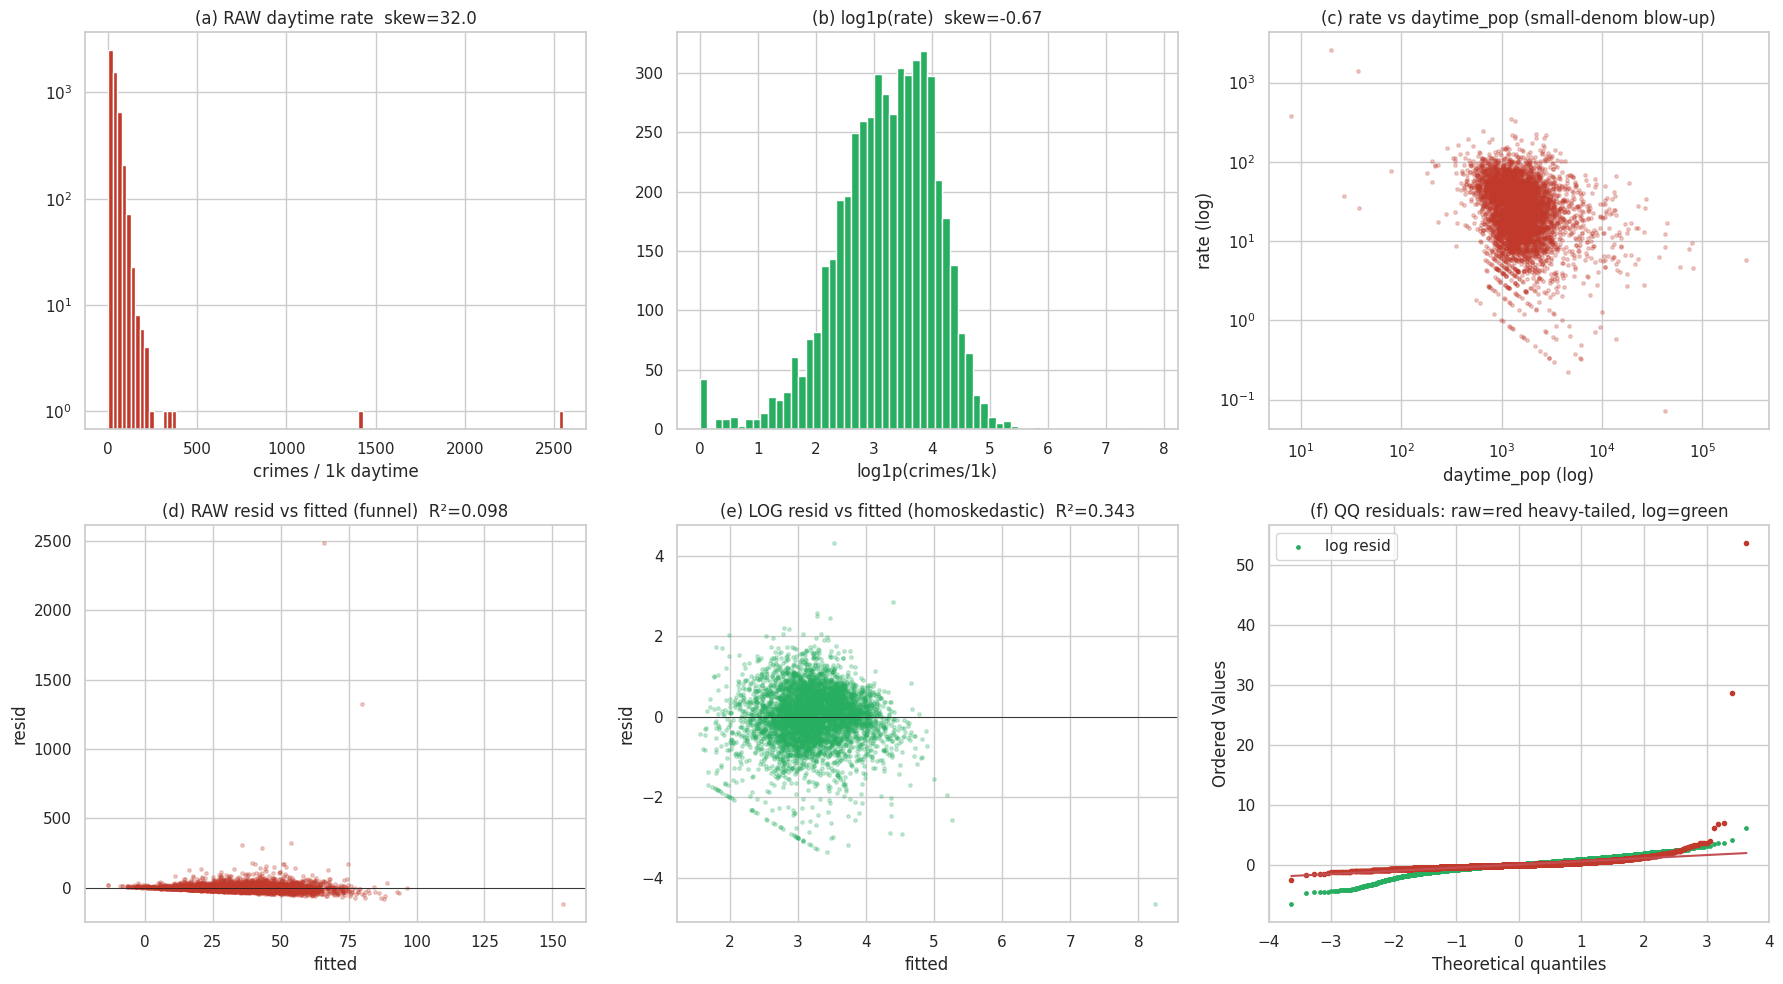

In [19]:
# Distributional diagnosis: raw daytime rate vs log — why OLS R² differs so much
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

RATE_COL = "cl_total_rate_daytime"   # daytime denominator (population + LODES jobs), per 1k

# pooled rows with population and all predictors present
d = df_all[df_all["population"] > 0].copy()
X = d[PREDICTOR_COLS].astype(float).replace([np.inf, -np.inf], np.nan)
ok = X.notna().all(axis=1)
d, X = d[ok], X[ok]
y_rate = d[RATE_COL].replace([np.inf, -np.inf], np.nan)
m = y_rate.notna()
d, X, y_rate = d[m], X[m], y_rate[m]
y_log = np.log1p(y_rate)

Xc = sm.add_constant(X.values)
fr = sm.OLS(y_rate.values, Xc).fit()   # raw rate
fl = sm.OLS(y_log.values,  Xc).fit()   # log1p rate
print(f"n={len(d)}  raw adjR2={fr.rsquared_adj:.3f}  log adjR2={fl.rsquared_adj:.3f}")
print(f"raw:  skew={stats.skew(y_rate):.1f}  kurt={stats.kurtosis(y_rate):.0f}")
print(f"log:  skew={stats.skew(y_log):.2f}  kurt={stats.kurtosis(y_log):.2f}")

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax[0,0].hist(y_rate, bins=100, color="#c0392b"); ax[0,0].set_yscale("log")
ax[0,0].set_title(f"(a) RAW daytime rate  skew={stats.skew(y_rate):.1f}"); ax[0,0].set_xlabel("crimes / 1k daytime")
ax[0,1].hist(y_log, bins=60, color="#27ae60")
ax[0,1].set_title(f"(b) log1p(rate)  skew={stats.skew(y_log):.2f}"); ax[0,1].set_xlabel("log1p(crimes/1k)")
ax[0,2].scatter(d["daytime_pop"], y_rate, s=6, alpha=.25, color="#c0392b")
ax[0,2].set_xscale("log"); ax[0,2].set_yscale("log")
ax[0,2].set_title("(c) rate vs daytime_pop (small-denom blow-up)"); ax[0,2].set_xlabel("daytime_pop (log)"); ax[0,2].set_ylabel("rate (log)")
ax[1,0].scatter(fr.fittedvalues, fr.resid, s=6, alpha=.25, color="#c0392b"); ax[1,0].axhline(0, c="k", lw=.6)
ax[1,0].set_title(f"(d) RAW resid vs fitted (funnel)  R²={fr.rsquared_adj:.3f}"); ax[1,0].set_xlabel("fitted"); ax[1,0].set_ylabel("resid")
ax[1,1].scatter(fl.fittedvalues, fl.resid, s=6, alpha=.25, color="#27ae60"); ax[1,1].axhline(0, c="k", lw=.6)
ax[1,1].set_title(f"(e) LOG resid vs fitted (homoskedastic)  R²={fl.rsquared_adj:.3f}"); ax[1,1].set_xlabel("fitted"); ax[1,1].set_ylabel("resid")
stats.probplot(fr.resid / fr.resid.std(), dist="norm", plot=ax[1,2])
qq = stats.probplot(fl.resid / fl.resid.std(), dist="norm")
ax[1,2].scatter(qq[0][0], qq[0][1], s=6, color="#27ae60", label="log resid")
ax[1,2].get_lines()[0].set_color("#c0392b"); ax[1,2].get_lines()[0].set_markersize(3)
ax[1,2].set_title("(f) QQ residuals: raw=red heavy-tailed, log=green"); ax[1,2].legend()
plt.tight_layout(); plt.show()

### Inspect the extreme block groups (daytime rate ≥ 250)

The skew is manufactured by ~7 BGs (0.13%). But they are **not all the same kind of point**:
tiny-denominator *artifacts* (`daytime_pop` ≤ ~100, a handful of crimes over almost no people)
vs. **genuine hotspots** (hundreds of crimes over a solid daytime population). A blind rate-cap
would clip the real hotspots too — a `daytime_pop` floor separates the two cleanly.

In [20]:
# The BGs driving the skew — artifact vs real?
import numpy as np
_cols = ["city","geoid","cl_total_count","population","c000","daytime_pop",
         "cl_total_rate","cl_total_rate_daytime"]
_ex = (df_all[df_all["population"] > 0]
       .loc[df_all["cl_total_rate_daytime"] >= 250, _cols]
       .sort_values("cl_total_rate_daytime", ascending=False))
_ex

,city,geoid,cl_total_count,population,c000,daytime_pop,cl_total_rate,cl_total_rate_daytime
2730,chicago,170313511001,59.0,10.0,0.0,10.0,5900.000000,5900.000000
872,houston,482014223032,51.0,18.0,2.0,20.0,2833.333333,2550.000000
4939,detroit,261635223003,52.0,34.0,3.0,37.0,1529.411765,1405.405405
4805,detroit,261635068003,3.0,7.0,1.0,8.0,428.571429,375.000000
1868,chicago,170310609002,39.0,30.0,77.0,107.0,1300.000000,364.485981
575,houston,482013331002,428.0,813.0,419.0,1232.0,526.445264,347.402597
1072,houston,482014329043,444.0,1310.0,48.0,1358.0,338.931298,326.951399


**Threshold sweep: how far does treating the rate get us?**
Compare *dropping* vs *winsorizing (capping)* vs a *daytime_pop floor*, on the raw daytime-rate
target (no log). Log1p is shown only as an aspirational ceiling — we keep **rate** as the modeled
variable for interpretability (no `e^x` back-transform).

In [21]:
# Raw-rate treatment sweep — adj R² on cl_total_rate_daytime
import numpy as np, pandas as pd, statsmodels.api as sm
from scipy import stats

d = df_all[df_all["population"] > 0].copy()
X = d[PREDICTOR_COLS].astype(float).replace([np.inf, -np.inf], np.nan)
ok = X.notna().all(axis=1); d, X = d[ok], X[ok]
r = d["cl_total_rate_daytime"].replace([np.inf, -np.inf], np.nan)
m = r.notna(); d, X, r = d[m], X[m], r[m]
dp = d["daytime_pop"]

def adj_r2(y, mask=None):
    yy = y if mask is None else y[mask]
    XX = X.values if mask is None else X[mask].values
    return sm.OLS(yy.values, sm.add_constant(XX)).fit().rsquared_adj

rows = []
rows.append(("none (raw rate)",           len(r), adj_r2(r),                 stats.skew(r)))
for thr in [500, 400, 300, 250, 200]:
    keep = r < thr
    rows.append((f"drop rate ≥ {thr}",     keep.sum(), adj_r2(r, keep),      stats.skew(r[keep])))
for cap in [500, 300, 250, 200]:
    rc = r.clip(upper=cap)
    rows.append((f"winsorize @ {cap}",      len(rc), adj_r2(rc),             stats.skew(rc)))
for floor in [50, 100, 150, 250]:
    keep = dp >= floor
    rows.append((f"daytime_pop floor ≥ {floor}", keep.sum(), adj_r2(r, keep), stats.skew(r[keep])))
rows.append(("log1p(rate) — aspirational", len(r), adj_r2(np.log1p(r)),      np.nan))

sweep = pd.DataFrame(rows, columns=["treatment", "n", "adj_R2", "skew"]).round({"adj_R2": 3, "skew": 2})
sweep

,treatment,n,adj_R2,skew
0,none (raw rate),5020,0.098,32.01
1,drop rate ≥ 500,5018,0.265,2.56
2,drop rate ≥ 400,5018,0.265,2.56
3,drop rate ≥ 300,5015,0.286,1.87
4,drop rate ≥ 250,5015,0.286,1.87
5,drop rate ≥ 200,5008,0.295,1.56
6,winsorize @ 500,5020,0.247,3.82
7,winsorize @ 300,5020,0.266,2.48
8,winsorize @ 250,5020,0.274,2.18
9,winsorize @ 200,5020,0.281,1.90
